# `so-bfw` — System optimum by bi-conjugate Frank–Wolfe on the Braess network

**What.** The system optimum (SO) minimises TOTAL travel time rather than letting
each traveller minimise their own — Wardrop's *second* principle. It is the same
Beckmann machinery run on **marginal-cost** link functions, so `so-bfw` reuses the
bi-conjugate Frank–Wolfe solver against `t_a + v_a t_a'` (`[sheffi1985urban]`,
[docs/REFERENCES.md](../../docs/REFERENCES.md)).

**Why it is in the benchmark.** It is the reference for the price of anarchy and
marginal-cost tolling, and the SO half of the equilibrium picture. See the
[model compendium](../../docs/MODELS.md) and
[docs/ARCHITECTURE.md](../../docs/ARCHITECTURE.md) (P1).

**Scope.** Runs on the built-in Braess scenario and certifies the SO gap; it then
contrasts the SO flows with the selfish (UE) equilibrium recomputed in-cell — the
Braess point. It is not a Wardrop UE solver — see [`bfw`](05-bfw.ipynb).

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every scored
quantity below is recomputed live by the P1 `Evaluator` from the flows the model
emitted, in the cell where it is claimed. Model self-reports are shown only as
provenance and diffed against the certificate as an honesty check, exactly as the
harness treats them ([README](../../README.md), *Certified, not self-reported*).

In [1]:
# Setup. `so-bfw` is a core model: a plain `pip install -e .` suffices — no
# optional extra, so no guard cell. The inline backend is Agg-based (headless CI
# renders into the notebook); NEVER matplotlib.use("Agg") in-kernel — it silently
# suppresses inline figure capture.
%matplotlib inline
import numpy as np

from tabench import (
    Budget,
    Evaluator,
    RngBundle,
    SystemOptimumModel,
    Trace,
    braess_scenario,
    viz,
)

## The scenario

The built-in Braess network: 4 nodes, 5 links, a single OD pair (1 → 2) with demand
6. Scenarios are frozen and content-hashed (P2) — the hash printed below is the
identity of the benchmark instance, so a silently edited network cannot masquerade
as it.

In [2]:
scenario = braess_scenario()
net = scenario.network

print(f"scenario      : {scenario.name}")
print(f"content hash  : {scenario.content_hash()[:16]}…")
print(f"links         : {net.n_links}  (tail→head: "
      + ", ".join(f"{i}->{j}" for i, j in zip(net.init_node, net.term_node)) + ")")
print(f"total demand  : {scenario.demand.total}")

scenario      : braess
content hash  : cf00f411cdccec88…
links         : 5  (tail→head: 1->3, 1->4, 3->4, 3->2, 4->2)
total demand  : 6.0


## Solve

The model contract ([CONTRIBUTING.md](../../CONTRIBUTING.md)): a model receives
`(scenario, budget, rng, trace)`, records checkpoints, and respects the budget.
Budgets are hardware-free (iterations / shortest-path calls; wall-clock is recorded
but never the ranking axis, P7). Whatever the model writes into `self_report` is
provenance, not a score.

In [3]:
model = SystemOptimumModel()
bundle = model.solve(scenario, Budget(iterations=200), RngBundle(0), Trace())

final = bundle.final
print(f"model              : {model.name}")
print(f"budget spent       : {final.coords.iterations} iterations, "
      f"{final.coords.sp_calls} shortest-path calls")
print(f"emitted SO flows   : {np.round(final.link_flows, 6)}")
print(f"self-reported SO gap: {final.self_report['so_relative_gap']:.3e}  (provenance only)")

model              : so-bfw
budget spent       : 4 iterations, 5 shortest-path calls
emitted SO flows   : [3. 3. 0. 3. 3.]
self-reported SO gap: 0.000e+00  (provenance only)


## Certify (P1)

The SO is scored by its own relative gap on the **marginal** cost, recomputed by an
`Evaluator` with `so_metrics=True`. We then recompute the selfish UE in-cell to make
the Braess point concrete: the SO AVOIDS the paradox-inducing bypass 3→4 entirely,
and its total travel time is strictly below the UE's — the price of anarchy.

In [4]:
ue_flows = np.array([4.0, 2.0, 2.0, 2.0, 4.0])  # the Wardrop UE, for contrast

evaluator = Evaluator(scenario, so_metrics=True, root_seed=0)
metrics = evaluator.evaluate(final.link_flows)
so_gap = metrics["so_relative_gap"]
print(f"certified SO relative gap : {so_gap:.3e}")
print(f"feasible                  : {metrics['feasible']:.0f}")

assert metrics["feasible"] == 1.0
assert abs(so_gap) < 1e-8

# Honesty diff (P1): the SO self-report matches the certificate.
assert np.isclose(final.self_report["so_relative_gap"], so_gap, rtol=1e-9, atol=1e-12)

# Anchor RECOMPUTED: the Braess SO puts ZERO flow on the bypass 3->4, and its total
# travel time is strictly below the selfish UE's (the price of anarchy).
bypass = next(
    k for k in range(net.n_links) if net.init_node[k] == 3 and net.term_node[k] == 4
)
print(f"bypass (3->4) SO flow     : {final.link_flows[bypass]:.3e}")
assert final.link_flows[bypass] < 1e-6

so_tstt = metrics["tstt"]
ue_tstt = evaluator.evaluate(ue_flows)["tstt"]
print(f"SO total time (TSTT)      : {so_tstt:.3f}")
print(f"UE total time (TSTT)      : {ue_tstt:.3f}")
print(f"price of anarchy (UE/SO)  : {ue_tstt / so_tstt:.4f}")
assert so_tstt < ue_tstt

certified SO relative gap : 0.000e+00
feasible                  : 1
bypass (3->4) SO flow     : 0.000e+00
SO total time (TSTT)      : 498.000
UE total time (TSTT)      : 552.000
price of anarchy (UE/SO)  : 1.1084


## Visualize

Both figures come from `tabench.viz`. Left/top: the SO link flows on the Braess
diamond — the 3→4 bypass carries ZERO flow (the SO refuses the paradox link).
Right/bottom: the SO flows against the selfish UE recomputed above; the points sit
OFF the `y = x` guide — SO and UE are different flows, which is the whole point.

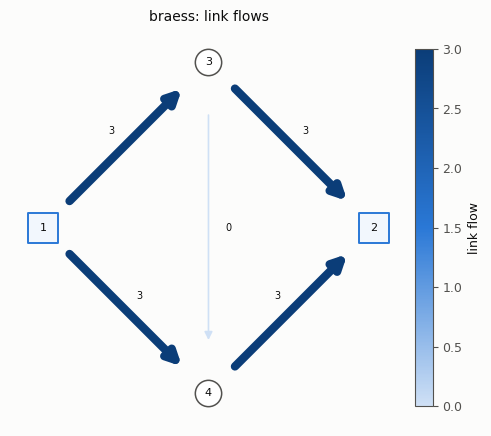

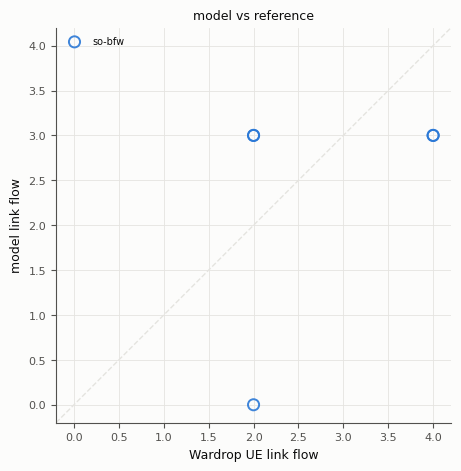

In [5]:
display(viz.plot_network_flows(net, final.link_flows))
display(viz.plot_flow_scatter(("Wardrop UE", ue_flows), {"so-bfw": final.link_flows}))

## Takeaways & pointers

- **Certified, not self-reported.** The SO gap came from `Evaluator(so_metrics=True)`;
  the self-report was only diffed against it.
- **The Braess point, computed.** The SO avoids the bypass and beats the UE's total
  time — the price of anarchy printed above, recomputed in-cell, not quoted.
- **Where next.** The selfish equilibrium it improves on: [`bfw`](05-bfw.ipynb); the SO
  design and marginal-cost tolls in the [model compendium](../../docs/MODELS.md).